In [1]:
import os, math, copy, tarfile, urllib.request, itertools
from pathlib import Path
from collections import defaultdict, Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

In [21]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

device: cuda


In [2]:
DATA_DIR = Path("./data")
OUTPUT_DIR = Path("./outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

IMAGE_SIZE = 32
NUM_CLASSES = 10
SAMPLES_PER_CLASS = 10
BATCH_SIZE = 32

TIME_MODE = "sinusoidal"
BASE_CHANNELS = 96
TIME_EMB_DIM = 128

NUM_STEPS = 10000
LR = 1e-4
GRAD_CLIP = 5.0

SAME_TIME_PROB = 0.10
ENDPOINT_PROB = 0.70
ENDPOINT_AUX_WEIGHT = 0.10

USE_EMA = True
EMA_DECAY = 0.999

In [3]:
IMAGENETTE_URL = "https://s3.amazonaws.com/fast-ai-imageclas/imagenette2-160.tgz"

In [4]:
def download_imagenette(data_dir=Path("./data")):
    data_dir = Path(data_dir)
    data_dir.mkdir(parents=True, exist_ok=True)
    tar_path = data_dir / "imagenette2-160.tgz"
    extract_path = data_dir / "imagenette2-160"
    if extract_path.exists():
        print("Imagenette already exists:", extract_path)
        return extract_path
    if not tar_path.exists():
        print("Downloading Imagenette...")
        urllib.request.urlretrieve(IMAGENETTE_URL, tar_path)
    print("Extracting Imagenette...")
    with tarfile.open(tar_path, "r:gz") as tar:
        tar.extractall(data_dir)
    return extract_path

In [6]:
def get_transform(image_size=32):
    return transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
        transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5)),
    ])

In [7]:
def load_imagenette(data_dir=Path("./data"), image_size=32, split="train"):
    extract_path = download_imagenette(data_dir)
    split_path = extract_path / split
    return datasets.ImageFolder(root=split_path, transform=get_transform(image_size))

In [8]:
def make_10_class_subset(full_dataset, num_classes=10, samples_per_class=10):
    chosen_classes = []
    for _, label in full_dataset:
        label = int(label)
        if label not in chosen_classes:
            chosen_classes.append(label)
        if len(chosen_classes) == num_classes:
            break

    label_map = {old: new for new, old in enumerate(chosen_classes)}
    selected_images, selected_labels = [], []
    class_counts = defaultdict(int)

    for img, label in full_dataset:
        label = int(label)
        if label in label_map and class_counts[label] < samples_per_class:
            selected_images.append(img)
            selected_labels.append(label_map[label])
            class_counts[label] += 1

        if all(class_counts[c] >= samples_per_class for c in chosen_classes):
            break

    images = torch.stack(selected_images, dim=0)
    labels = torch.tensor(selected_labels, dtype=torch.long)
    return ImageTensorDataset(images, labels), chosen_classes, label_map

In [9]:
class ImageTensorDataset(Dataset):
    def __init__(self, images, labels):
        self.images = images
        self.labels = labels
    def __len__(self):
        return self.images.shape[0]
    def __getitem__(self, idx):
        return self.images[idx], self.labels[idx]

In [10]:
full_dataset = load_imagenette(DATA_DIR, image_size=IMAGE_SIZE, split="train")
ten_class_dataset, chosen_classes, label_map = make_10_class_subset(
    full_dataset, NUM_CLASSES, SAMPLES_PER_CLASS
)
ten_class_dataloader = DataLoader(
    ten_class_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True
)

print("chosen class ids:", chosen_classes)
print("class names:", [full_dataset.classes[i] for i in chosen_classes])
print("label map:", label_map)
print("label counts:", Counter(ten_class_dataset.labels.tolist()))

x_batch, y_batch = next(iter(ten_class_dataloader))
print("x:", x_batch.shape, x_batch.min().item(), x_batch.max().item())
print("y:", y_batch.shape, y_batch.min().item(), y_batch.max().item(), torch.unique(y_batch))

Extracting Imagenette...


/tmp/ipykernel_721/2499078696.py:14: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(data_dir)


chosen class ids: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
class names: ['n01440764', 'n02102040', 'n02979186', 'n03000684', 'n03028079', 'n03394916', 'n03417042', 'n03425413', 'n03445777', 'n03888257']
label map: {0: 0, 1: 1, 2: 2, 3: 3, 4: 4, 5: 5, 6: 6, 7: 7, 8: 8, 9: 9}
label counts: Counter({0: 10, 1: 10, 2: 10, 3: 10, 4: 10, 5: 10, 6: 10, 7: 10, 8: 10, 9: 10})
x: torch.Size([32, 3, 32, 32]) -1.0 1.0
y: torch.Size([32]) 0 9 tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])


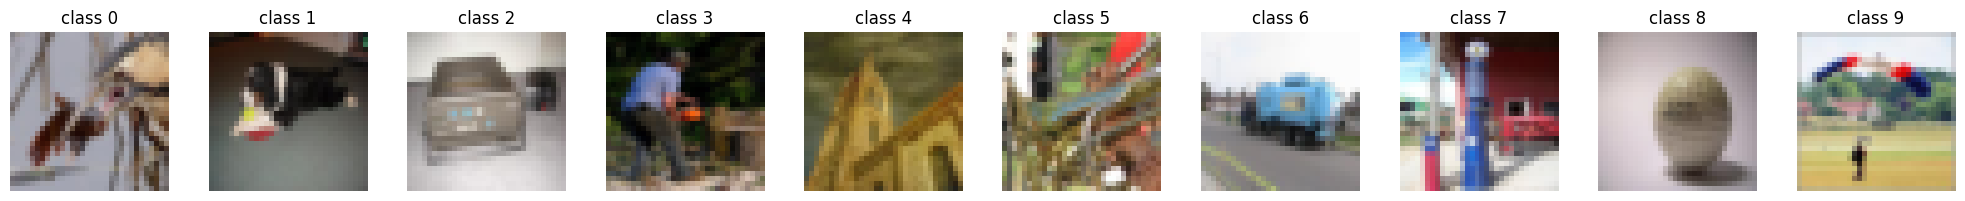

In [11]:
def denormalize_img(x):
    return ((x + 1) / 2).clamp(0, 1)

def get_one_original_per_class(dataloader, num_classes=10):
    originals = [None] * num_classes
    for x, y in dataloader:
        for img, label in zip(x, y):
            label = int(label)
            if originals[label] is None:
                originals[label] = img
        if all(img is not None for img in originals):
            break
    return torch.stack(originals, dim=0)

originals = get_one_original_per_class(ten_class_dataloader, NUM_CLASSES)

fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(2*NUM_CLASSES, 2))
for i in range(NUM_CLASSES):
    axes[i].imshow(denormalize_img(originals[i]).permute(1,2,0))
    axes[i].set_title(f"class {i}")
    axes[i].axis("off")
plt.tight_layout()
plt.show()


In [12]:
def make_group_norm(ch, max_groups=8):
    groups = min(max_groups, ch)
    while ch % groups != 0:
        groups -= 1
    return nn.GroupNorm(groups, ch)

In [13]:
class SinusoidalEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim
    def forward(self, x):
        half_dim = self.dim // 2
        freqs = torch.exp(
            -math.log(1000) * torch.arange(half_dim, device=x.device) / (half_dim - 1)
        )
        args = x[:, None] * freqs[None, :]
        emb = torch.cat([torch.sin(args), torch.cos(args)], dim=-1)
        if self.dim % 2 == 1:
            emb = F.pad(emb, (0, 1))
        return emb

In [14]:
class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, time_dim):
        super().__init__()
        self.norm1 = make_group_norm(in_ch)
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.time_proj = nn.Linear(time_dim, out_ch)
        self.norm2 = make_group_norm(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.skip = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x, temb):
        h = self.conv1(F.silu(self.norm1(x)))
        h = h + self.time_proj(temb)[:, :, None, None]
        h = self.conv2(F.silu(self.norm2(h)))
        return h + self.skip(x)

In [15]:
class MeanFlowUNet(nn.Module):
    def __init__(self, img_channels=3, base_channels=96, time_emb_dim=128,
                 num_classes=10, time_mode="sinusoidal"):
        super().__init__()
        self.time_mode = time_mode

        if time_mode == "sinusoidal":
            self.time_embed = SinusoidalEmbedding(time_emb_dim)
            time_input_dim = time_emb_dim * 2
        elif time_mode == "scalar":
            self.time_embed = None
            time_input_dim = 2
        else:
            raise ValueError("time_mode must be 'sinusoidal' or 'scalar'")

        self.time_mlp = nn.Sequential(
            nn.Linear(time_input_dim, time_emb_dim * 4),
            nn.SiLU(),
            nn.Linear(time_emb_dim * 4, time_emb_dim),
        )
        self.label_embed = nn.Embedding(num_classes, time_emb_dim)

        self.in_conv = nn.Conv2d(img_channels, base_channels, 3, padding=1)

        self.res1 = ResBlock(base_channels, base_channels, time_emb_dim)
        self.down1 = nn.Conv2d(base_channels, base_channels*2, 4, stride=2, padding=1)

        self.res2 = ResBlock(base_channels*2, base_channels*2, time_emb_dim)
        self.down2 = nn.Conv2d(base_channels*2, base_channels*4, 4, stride=2, padding=1)

        self.mid = ResBlock(base_channels*4, base_channels*4, time_emb_dim)

        self.up1 = nn.ConvTranspose2d(base_channels*4, base_channels*2, 4, stride=2, padding=1)
        self.res_up1 = ResBlock(base_channels*2, base_channels*2, time_emb_dim)

        self.up2 = nn.ConvTranspose2d(base_channels*2, base_channels, 4, stride=2, padding=1)
        self.res_up2 = ResBlock(base_channels, base_channels, time_emb_dim)

        self.out_norm = make_group_norm(base_channels)
        self.out_conv = nn.Conv2d(base_channels, img_channels, 3, padding=1)

    def forward(self, z, r, t, y=None):
        B = z.shape[0]
        r = r.view(B)
        t = t.view(B)
        dt = t - r

        if self.time_mode == "sinusoidal":
            temb = torch.cat([self.time_embed(t), self.time_embed(dt)], dim=-1)
        else:
            temb = torch.stack([t, dt], dim=1)

        temb = self.time_mlp(temb)
        if y is not None:
            temb = temb + self.label_embed(y)

        h1 = self.res1(self.in_conv(z), temb)
        h2 = self.res2(self.down1(h1), temb)
        h3 = self.mid(self.down2(h2), temb)

        h = self.res_up1(self.up1(h3) + h2, temb)
        h = self.res_up2(self.up2(h) + h1, temb)
        return self.out_conv(F.silu(self.out_norm(h)))


In [16]:
def sample_r_t(batch_size, device, same_time_prob=0.10, endpoint_prob=0.70):
    a = torch.rand(batch_size, device=device)
    b = torch.rand(batch_size, device=device)

    t = torch.maximum(a, b)
    r = torch.minimum(a, b)

    same_mask = torch.rand(batch_size, device=device) < same_time_prob
    r = torch.where(same_mask, t, r)

    endpoint_mask = torch.rand(batch_size, device=device) < endpoint_prob
    r = torch.where(endpoint_mask, torch.zeros_like(r), r)
    t = torch.where(endpoint_mask, torch.ones_like(t), t)

    return r, t

In [17]:
def meanflow_loss(model, x, y=None, same_time_prob=0.10,
                  endpoint_prob=0.70, endpoint_aux_weight=0.10):
    B = x.shape[0]
    device = x.device

    eps = torch.randn_like(x)
    r, t = sample_r_t(B, device, same_time_prob, endpoint_prob)

    t_img = t[:, None, None, None]
    z_t = (1.0 - t_img) * x + t_img * eps
    v = eps - x

    def fn(z_in, r_in, t_in):
        return model(z_in, r_in, t_in, y)

    u, dudt = torch.func.jvp(
        fn,
        (z_t, r, t),
        (v, torch.zeros_like(r), torch.ones_like(t)),
    )

    dt = (t - r)[:, None, None, None]
    u_tgt = v - dt * dudt
    mf_loss = ((u - u_tgt.detach()) ** 2).mean()

    # Endpoint auxiliary loss.
    if endpoint_aux_weight > 0:
        eps_end = torch.randn_like(x)
        r_end = torch.zeros(B, device=device)
        t_end = torch.ones(B, device=device)
        u_end = model(eps_end, r_end, t_end, y)
        x_hat = eps_end - u_end
        endpoint_loss = ((x_hat - x) ** 2).mean()
        loss = mf_loss + endpoint_aux_weight * endpoint_loss
    else:
        endpoint_loss = torch.tensor(0.0, device=device)
        loss = mf_loss

    return loss, mf_loss.detach(), endpoint_loss.detach()


In [18]:
def update_ema(ema_model, model, decay=0.999):
    with torch.no_grad():
        for ema_p, p in zip(ema_model.parameters(), model.parameters()):
            ema_p.data.mul_(decay).add_(p.data, alpha=1 - decay)

In [19]:
def train_meanflow_steps(model, dataloader, device, num_steps=10000,
                         lr=1e-4, grad_clip=5.0, use_ema=True, ema_decay=0.999):
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.0)

    ema_model = None
    if use_ema:
        ema_model = copy.deepcopy(model).to(device)
        for p in ema_model.parameters():
            p.requires_grad_(False)

    loss_history, mf_history, endpoint_history = [], [], []
    data_iter = itertools.cycle(dataloader)
    model.train()

    pbar = tqdm(range(num_steps))
    for step in pbar:
        x, y = next(data_iter)
        x = x.to(device)
        y = y.to(device)

        loss, mf_loss, endpoint_loss = meanflow_loss(
            model, x, y,
            same_time_prob=SAME_TIME_PROB,
            endpoint_prob=ENDPOINT_PROB,
            endpoint_aux_weight=ENDPOINT_AUX_WEIGHT,
        )

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        optimizer.step()

        if ema_model is not None:
            update_ema(ema_model, model, ema_decay)

        loss_history.append(loss.item())
        mf_history.append(mf_loss.item())
        endpoint_history.append(endpoint_loss.item())

        if step % 100 == 0:
            pbar.set_description(f"step={step} loss={loss.item():.5f}")

    return model, ema_model, loss_history, mf_history, endpoint_history


In [22]:
model = MeanFlowUNet(
    img_channels=3,
    base_channels=BASE_CHANNELS,
    time_emb_dim=TIME_EMB_DIM,
    num_classes=NUM_CLASSES,
    time_mode=TIME_MODE,
).to(device)

In [23]:
# Training with EMA
model, ema_model, loss_history, mf_history, endpoint_history = train_meanflow_steps(
    model, ten_class_dataloader, device,
    num_steps=NUM_STEPS,
    lr=LR,
    grad_clip=GRAD_CLIP,
    use_ema=USE_EMA,
    ema_decay=EMA_DECAY,
)

  0%|          | 0/10000 [00:00<?, ?it/s]

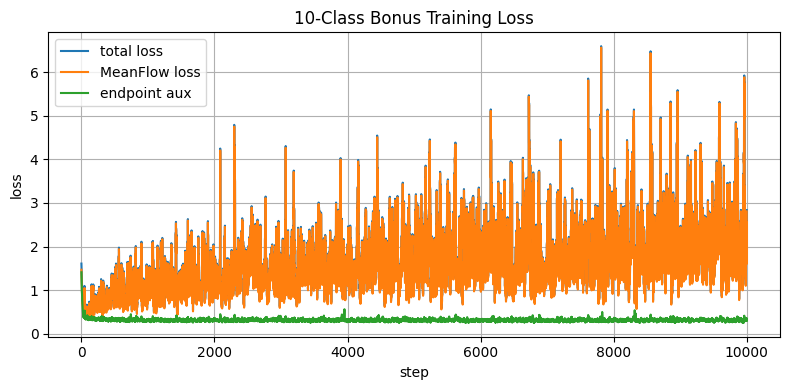

In [7]:
plt.figure(figsize=(8,4))
plt.plot(loss_history, label="total loss")
plt.plot(mf_history, label="MeanFlow loss")
plt.plot(endpoint_history, label="endpoint aux")
plt.xlabel("step")
plt.ylabel("loss")
plt.title("10-Class Bonus Training Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "bonus_10_class_loss_curve.png", dpi=200, bbox_inches="tight")
plt.show()


## One-step generation


In [24]:
@torch.no_grad()
def generate_one_per_class(model, device, num_classes=10, image_size=32):
    model.eval()
    z = torch.randn(num_classes, 3, image_size, image_size, device=device)
    r = torch.zeros(num_classes, device=device)
    t = torch.ones(num_classes, device=device)
    y = torch.arange(num_classes, dtype=torch.long, device=device)

    u = model(z, r, t, y)
    x_gen = z - u
    return x_gen

In [25]:
def plot_original_vs_generated(originals, generated, save_path=None):
    num_classes = originals.shape[0]
    fig, axes = plt.subplots(num_classes, 2, figsize=(5, 2.2*num_classes))

    for i in range(num_classes):
        orig_img = denormalize_img(originals[i].detach().cpu()).permute(1,2,0)
        gen_img = denormalize_img(generated[i].detach().cpu()).permute(1,2,0)

        axes[i,0].imshow(orig_img)
        axes[i,0].set_title(f"Original class {i}")
        axes[i,0].axis("off")

        axes[i,1].imshow(gen_img)
        axes[i,1].set_title(f"Generated class {i}")
        axes[i,1].axis("off")

    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()

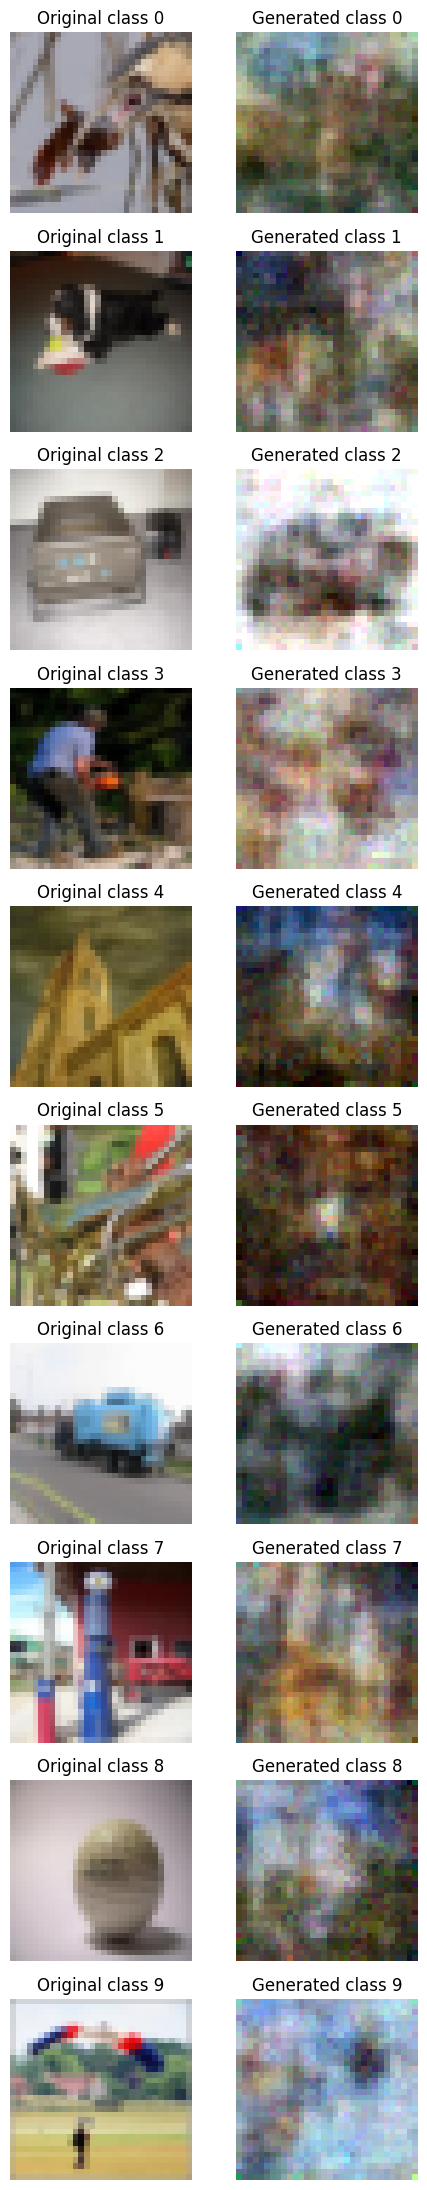

In [26]:
sample_model = ema_model if ema_model is not None else model
generated = generate_one_per_class(sample_model, device, NUM_CLASSES, IMAGE_SIZE)

plot_original_vs_generated(
    originals,
    generated,
    save_path=OUTPUT_DIR / "bonus_10_class_original_vs_generated.png",
)

In [28]:
@torch.no_grad()
def generate_samples_per_class(model, device, num_classes=10, samples_per_class=4, image_size=32):
    model.eval()
    total = num_classes * samples_per_class
    z = torch.randn(total, 3, image_size, image_size, device=device)
    r = torch.zeros(total, device=device)
    t = torch.ones(total, device=device)
    y = torch.tensor(
        [c for c in range(num_classes) for _ in range(samples_per_class)],
        dtype=torch.long,
        device=device,
    )
    u = model(z, r, t, y)
    return z - u, y

In [29]:
def plot_generated_grid(generated, num_classes=10, samples_per_class=4, save_path=None):
    fig, axes = plt.subplots(num_classes, samples_per_class, figsize=(2*samples_per_class, 2*num_classes))
    for i in range(num_classes):
        for j in range(samples_per_class):
            idx = i * samples_per_class + j
            img = denormalize_img(generated[idx].detach().cpu()).permute(1,2,0)
            axes[i,j].imshow(img)
            axes[i,j].axis("off")
            if j == 0:
                axes[i,j].set_title(f"class {i}")
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()

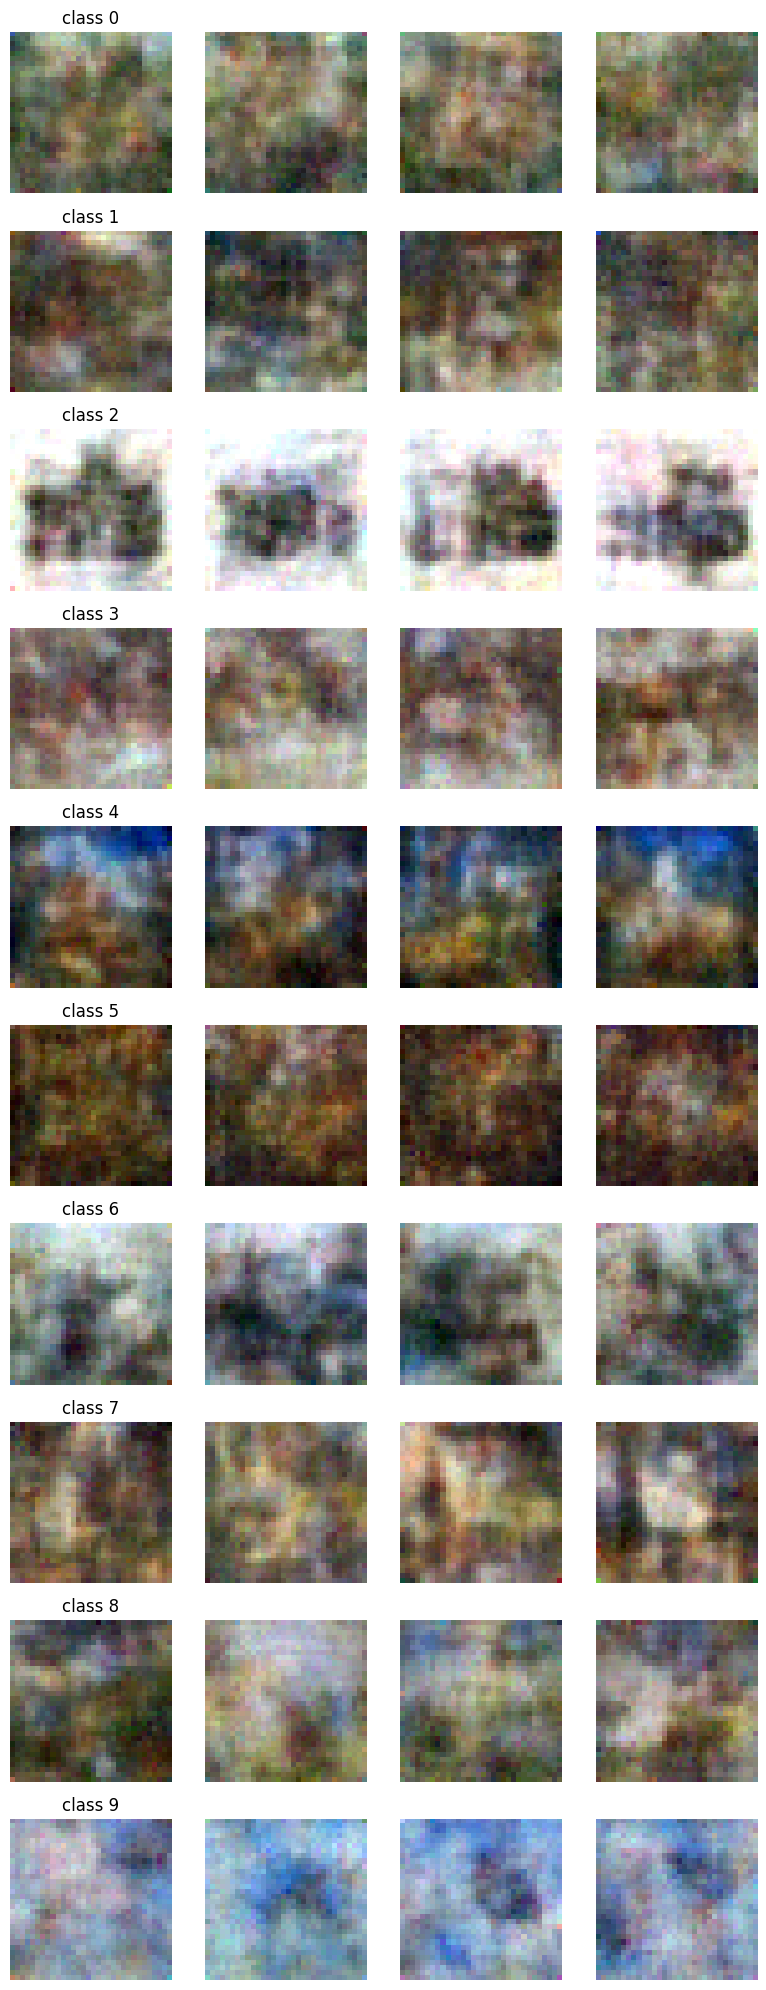

In [30]:
generated_multi, _ = generate_samples_per_class(sample_model, device, NUM_CLASSES, 4, IMAGE_SIZE)
plot_generated_grid(
    generated_multi,
    num_classes=NUM_CLASSES,
    samples_per_class=4,
    save_path=OUTPUT_DIR / "bonus_10_class_generated_grid.png",
)